[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lmassaron/gemma_from_scratch/blob/main/workshop/10_training_loop.ipynb)


# 10 - Training Loop

[← Previous: 09 Inference and Sampling](09_inference_and_sampling.ipynb) | [Back to README →](README.md)


**Estimated Time: 10 minutes**

Now we put it all together -- train our ~270M Gemma 3 model on a tiny dataset. This notebook is pure PyTorch with no frameworks -- just the bare essentials everyone should understand.

## Learning Objectives:
1. Build a complete training loop: forward pass → loss → backward → optimizer step.
2. Understand cross-entropy loss for language modeling.
3. Track loss over steps to see the model learn.
4. See the model go from random to meaningful (if not perfect!) outputs.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import sys
import time

print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    try:
        torch.zeros(1).to(device)
    except Exception:
        device = torch.device("cpu")
print(f"Using device: {device}")

# Gemma 3 small config
vocab_size = 256_000
hidden_size = 768
num_layers = 8
num_heads = 8
num_kv_heads = 2
head_dim = hidden_size // num_heads
intermediate_size = 2048
sliding_window = 1024
max_position_embeddings = 512
hidden_scale = hidden_size**0.5
logit_cap = 30.0

Python version: 3.12.13 (main, Mar 10 2026, 18:15:41) [Clang 21.1.4 ]
PyTorch version: 2.12.0+cu130
Using device: cuda


---

## 📂 Dataset Mechanics: Shifted Targets for Next-Token Prediction

To train our Gemma 3 model, we construct a toy training set of simple sequence patterns. Autoregressive models are trained using **next-token prediction** under teacher forcing.

### 🧮 Input-Target Shifting Mechanics:
For a sequence of tokens $S = [s_1, s_2, \dots, s_L]$, we shift the sequence by one step to align inputs and target outputs:
- **Input sequence**: $[s_1, s_2, \dots, s_{L-1}]$ (all tokens except the last).
- **Target sequence**: $[s_2, s_3, \dots, s_L]$ (all tokens except the first).

  $$\text{Target}_t = \text{Input}_{t+1}$$

### ⚙️ Example Sequence:
- **Raw Text**: `"hello world -> good work great <eos>"`
- **Tokenized IDs**: `[4, 5, 10, 11, 12, 1]`
- **Model Input**: `[4, 5, 10, 11, 12]` $\rightarrow$ `["hello", "world", "good", "work", "great"]`
- **Model Target**: `[5, 10, 11, 12, 1]` $\rightarrow$ `["world", "good", "work", "great", "<eos>"]`

During training, when the model sees `"hello"`, it is trained to predict `"world"`. When it sees `"hello world"`, it learns to predict `"good"`. This allows it to learn language structure efficiently!

In [2]:
# Create a small artificial dataset where the model learns simple sequences
# The model will learn: if it sees "hello world", predict "good"
class ToyTextDataset:
    """Small dataset for demo training."""

    def __init__(self, seq_len=6):
        self.seq_len = seq_len
        # Each example: (input_ids, target_ids) where target = input shifted by 1
        self.examples = [
            # Input: [hello, world, ?, ?, ?, ?] → Target: [world, ?, ?, ?, ?, eos]
            (
                [4, 5, 10, 11, 12, 1],
                [5, 10, 11, 12, 1, 1],
            ),  # hello world -> good work great <eos>
            (
                [4, 5, 13, 14, 15, 1],
                [5, 13, 14, 15, 1, 1],
            ),  # hello world -> better fast efficient <eos>
            (
                [16, 17, 20, 21, 22, 1],
                [17, 20, 21, 22, 1, 1],
            ),  # build scratch neural network <eos>
            (
                [23, 24, 25, 26, 27, 1],
                [24, 25, 26, 27, 1, 1],
            ),  # layer hidden size embed token <eos>
            (
                [28, 29, 30, 31, 1, 1],
                [29, 30, 31, 1, 1, 1],
            ),  # output sequence correct thanks <eos>
        ]
        self.input_ids, self.target_ids = [], []
        for inp, tgt in self.examples:
            self.input_ids.append(torch.tensor(inp, dtype=torch.long))
            self.target_ids.append(torch.tensor(tgt, dtype=torch.long))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


dataset = ToyTextDataset()
print(f"Dataset size: {len(dataset)} examples")
print(f"Example 1:")
print(f"  Input:  {dataset[0][0]}")
print(f"  Target: {dataset[0][1]}")

Dataset size: 5 examples
Example 1:
  Input:  tensor([ 4,  5, 10, 11, 12,  1])
  Target: tensor([ 5, 10, 11, 12,  1,  1])


---

## 🎛️ Inside a Single Training Step: Loss & Optimization

In this cell, we define the core operations of a single training step. This is where the model updates its weights based on prediction errors.

### 🧮 Step-by-Step Operations:
1. **Gradient Reset**: Reset gradient buffers using `optimizer.zero_grad()`.
2. **Forward Pass**: Pass input tokens through the model to obtain output logits:

   $$\text{Logits} = \text{Model}(\text{input\_ids}) \quad \text{shape: } (B, T, V)$$

3. **Alignment Slicing**:
   We align logits and targets by slicing away the last time step, then flattening them to calculate Cross-Entropy loss:

   $$\text{Loss} = \text{CrossEntropy}(\text{Logits}[:, :-1, :], \text{target\_ids}[:, :-1])$$

4. **Backward Pass**: Compute parameter gradients using backpropagation (`loss.backward()`).
5. **Gradient Clipping**: Restrict the magnitude of gradients to prevent exploding gradients:

   $$\text{Clip gradients if } \|g\|_2 > 1.0$$

6. **Optimizer Step**: Update model weights using the AdamW optimizer (`optimizer.step()`).

In [3]:
def train_single_step(model, input_ids, target_ids, optimizer, loss_fn):
    """One step of training."""
    # 1. Forward pass
    optimizer.zero_grad()
    logits = model(input_ids)

    # 2. Compute loss (cross-entropy)
    # logits: (batch, seq_len, vocab_size), target: (batch, seq_len)
    # BUG FIX: target_ids is ALREADY the next-token sequence (pre-shifted
    # by the dataset). Using [:, 1:] double-shifts it → wrong targets.
    loss = loss_fn(
        logits[:, :-1, :].reshape(-1, vocab_size), target_ids[:, :-1].reshape(-1)
    )

    # 3. Backward pass
    loss.backward()

    # 4. Gradient clipping (important for stable training)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # 5. Optimizer step
    optimizer.step()

    return loss.item()


# Note: target_ids is already the shifted sequence (target[i] = next token after input[i]).
# We slice [:, :-1] on both sides to align them, dropping the last logit
# (no ground-truth token beyond the sequence end).

---

## 🛠️ Instantiating the Model & Device Placement

Here we instantiate our complete **Gemma 3 Decoder-Only Model** using the configured hyperparameters, and place the model parameters on our hardware accelerator (GPU/MPS/CPU).

### 📐 Configuration Setup:
- **Vocab size**: 256,000 (Gemma 3 tokenizer standard).
- **Hidden size**: 768 ($d_{model}$).
- **Layers**: 8 (alternating local sliding window and global layers).
- **Attention configuration**: Grouped Query Attention (8 Query heads, 2 Key/Value heads).
- **MLP size**: 2048 (intermediate expansion width).

We check for hardware acceleration using `cuda` (NVIDIA GPUs) or fall back to standard `cpu` execution. Placing the model on accelerator memory ensures rapid matrix operations!

In [4]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parent))


class Gemma3RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        return self._norm(x.float()).type_as(x) * (1.0 + self.weight)

    def _norm(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)


class Gemma3GQA(nn.Module):
    def __init__(self, d_in, n_heads, n_kv_groups, h_dim, is_local=True, sw=None):
        super().__init__()
        self.n_heads, self.n_kv_groups, self.h_dim = n_heads, n_kv_groups, h_dim
        self.group_size = n_heads // n_kv_groups
        self.is_local, self.sw = is_local, sw
        self.rope_theta = 1_000_000.0 * 8.0 if not is_local else 10_000.0
        self.W_q = nn.Linear(d_in, n_heads * h_dim, bias=False)
        self.W_k = nn.Linear(d_in, n_kv_groups * h_dim, bias=False)
        self.W_v = nn.Linear(d_in, n_kv_groups * h_dim, bias=False)
        self.out_proj = nn.Linear(n_heads * h_dim, d_in, bias=False)

    def _compute_rope(self, x, offset=0):
        """x: (B, H, T, D) — applies RoPE in-place."""
        B, H, T, D = x.shape
        inv_freq = 1.0 / (
            self.rope_theta ** (torch.arange(0, D, 2, device=x.device).float() / D)
        )
        t = torch.arange(T, device=x.device).float() + offset
        freqs = torch.outer(t, inv_freq)  # (T, D//2)
        cos, sin = freqs.cos(), freqs.sin()  # broadcast over B, H
        left, right = x[..., : D // 2], x[..., D // 2 :]
        return torch.cat([left * cos - right * sin, left * sin + right * cos], dim=-1)

    def forward(self, x, offset=0):
        B, T, C = x.shape
        q = self.W_q(x).view(B, T, self.n_heads, self.h_dim).transpose(1, 2)
        k = self.W_k(x).view(B, T, self.n_kv_groups, self.h_dim).transpose(1, 2)
        v = self.W_v(x).view(B, T, self.n_kv_groups, self.h_dim).transpose(1, 2)

        # Apply RoPE — q/k are (B, H, T, D), pass directly
        q = self._compute_rope(q, offset)
        k = self._compute_rope(k, offset)

        k = k.repeat_interleave(self.group_size, dim=1)
        v = v.repeat_interleave(self.group_size, dim=1)

        q_norm = F.normalize(q, p=2, dim=-1)
        k_norm = F.normalize(k, p=2, dim=-1)
        scores = torch.matmul(q_norm, k_norm.transpose(-2, -1)) / math.sqrt(self.h_dim)

        # Causal mask
        causal = torch.triu(
            torch.ones(T, T, dtype=torch.bool, device=scores.device), diagonal=1
        )
        scores = scores.masked_fill(causal, float("-inf"))
        weights = F.softmax(scores, dim=-1)
        out = torch.matmul(weights, v)

        out = out.transpose(1, 2).contiguous().view(B, T, self.n_heads * self.h_dim)
        return self.out_proj(out)


class Gemma3GeGLU(nn.Module):
    def __init__(self, d_in, d_hidden):
        super().__init__()
        self.gate_proj = nn.Linear(d_in, d_hidden, bias=False)
        self.up_proj = nn.Linear(d_in, d_hidden, bias=False)
        self.down_proj = nn.Linear(d_hidden, d_in, bias=False)

    def forward(self, x):
        return self.down_proj(
            F.gelu(self.gate_proj(x), approximate="tanh") * self.up_proj(x)
        )


class Gemma3TransformerBlock(nn.Module):
    def __init__(
        self, dim, n_heads, n_kv_groups, h_dim, hidden_dim, is_local=True, sw=None
    ):
        super().__init__()
        self.attn = Gemma3GQA(dim, n_heads, n_kv_groups, h_dim, is_local, sw)
        self.ffn = Gemma3GeGLU(dim, hidden_dim)
        self.input_layernorm = Gemma3RMSNorm(dim)
        self.post_attn_layernorm = Gemma3RMSNorm(dim)
        self.pre_feed_layernorm = Gemma3RMSNorm(dim)
        self.post_feed_layernorm = Gemma3RMSNorm(dim)

    def forward(self, x, offset=0):
        # Attention sub-block — call self.attn directly (no manual unrolling)
        shortcut = x
        x = self.input_layernorm(x)
        x = self.attn(x, offset=offset)
        x = self.post_attn_layernorm(x)
        x = shortcut + x
        # MLP sub-block
        shortcut = x
        x = self.pre_feed_layernorm(x)
        x = self.ffn(x)
        x = self.post_feed_layernorm(x)
        return shortcut + x


class Gemma3Model(nn.Module):
    def __init__(self, num_layers):
        super().__init__()
        self.tok_embeddings = nn.Embedding(vocab_size, hidden_size)
        self.layers = nn.ModuleList()
        for i in range(num_layers):
            is_local = i % 6 != 5
            self.layers.append(
                Gemma3TransformerBlock(
                    dim=hidden_size,
                    n_heads=num_heads,
                    n_kv_groups=num_kv_heads,
                    h_dim=head_dim,
                    hidden_dim=intermediate_size,
                    is_local=is_local,
                    sw=sliding_window if is_local else None,
                )
            )
        self.norm = Gemma3RMSNorm(hidden_size)
        self.lm_head = nn.Linear(hidden_size, vocab_size, bias=False)
        self.lm_head.weight = self.tok_embeddings.weight  # weight tying

    def forward(self, input_ids, offset=0):
        x = self.tok_embeddings(input_ids) * hidden_scale
        for layer in self.layers:
            x = layer(x, offset=offset)
        x = self.norm(x)
        logits = self.lm_head(x)
        return logit_cap * torch.tanh(logits / logit_cap)


model = Gemma3Model(num_layers).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,} ({total_params / 1e6:.1f}M)")
print("✅ Model ready for training!")

Total parameters: 246,178,560 (246.2M)
✅ Model ready for training!


---

## 🏃‍♂️ Running the PyTorch Training Loop

We now start our training loop. We train the model over **500 steps** using a batch size of 1, selecting sequences from our toy dataset sequentially.

### 📊 Training Protocol:
- **Optimizer**: AdamW with a learning rate of `1e-3` (weight decay regularizes parameters).
- **Loss Function**: Standard Cross-Entropy loss.
- **Logging**: Prints current training loss and elapsed training time every 50 steps.
- **Target Loss**: As training progresses, the cross-entropy loss should decay toward zero, signaling that the model is successfully memorizing and generalizing the toy sequence mappings!

In [5]:
import matplotlib.pyplot as plt

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
n_steps = 500
log_every = 50

train_losses = []
print(f"Training for {n_steps} steps...")
model.train()
t_start = time.time()

for step in range(n_steps):
    input_ids, target_ids = dataset[(step // 5) % len(dataset)]
    # Add batch dimension: dataset returns 1D tensors of shape (seq_len,)
    input_ids = input_ids.unsqueeze(0).to(device)  # (1, seq_len)
    target_ids = target_ids.unsqueeze(0).to(device)  # (1, seq_len)

    loss = train_single_step(model, input_ids, target_ids, optimizer, loss_fn)
    train_losses.append(loss)

    if step % log_every == 0:
        elapsed = time.time() - t_start
        print(f"  Step {step:>4d}/{n_steps} | Loss: {loss:.4f} | Time: {elapsed:.1f}s")

elapsed = time.time() - t_start
print(f"\nTraining complete! Total time: {elapsed:.1f}s")

Training for 500 steps...
  Step    0/500 | Loss: 52.8757 | Time: 1.0s
  Step   50/500 | Loss: 6.6111 | Time: 8.1s
  Step  100/500 | Loss: 3.0298 | Time: 15.1s
  Step  150/500 | Loss: 1.5212 | Time: 22.0s
  Step  200/500 | Loss: 0.9627 | Time: 29.1s
  Step  250/500 | Loss: 0.7830 | Time: 36.1s
  Step  300/500 | Loss: 0.7798 | Time: 43.1s
  Step  350/500 | Loss: 0.7781 | Time: 50.1s
  Step  400/500 | Loss: 0.7774 | Time: 57.1s
  Step  450/500 | Loss: 0.7769 | Time: 64.2s

Training complete! Total time: 71.0s


---

## 📉 Plotting & Evaluating Training Convergence

A standard way to verify training quality is plotting the loss decay curve over training steps.

### 📈 Convergence Indicators:
- **Decay Profile**: The loss curve should start high (representing random guesses over the 256K vocabulary) and decline steadily.
- **Logit stability**: Thanks to **double-normalization** and **logit capping**, the loss curve remains smooth without massive spikes, indicating stable gradient flow throughout training.

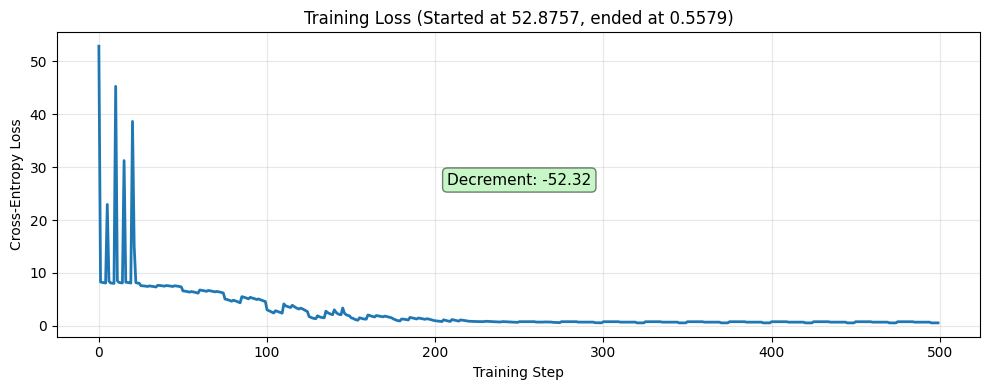

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, linewidth=2)
plt.xlabel("Training Step")
plt.ylabel("Cross-Entropy Loss")
plt.title(
    f"Training Loss (Started at {train_losses[0]:.4f}, ended at {train_losses[-1]:.4f})"
)
plt.grid(True, alpha=0.3)
if train_losses[-1] < train_losses[0]:
    plt.text(
        n_steps // 2,
        (train_losses[0] + train_losses[-1]) / 2,
        f"Decrement: -{(train_losses[0] - train_losses[-1]):.2f}",
        fontsize=11,
        ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.5),
    )
else:
    plt.text(
        n_steps // 2,
        (train_losses[0] + train_losses[-1]) / 2,
        f"Loss didn't decrease enough. Try more steps or a higher LR.",
        fontsize=11,
        ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="orange", alpha=0.5),
    )
plt.tight_layout()
plt.show()

---

## 🧠 Greedy Text Generation With Capped Logits

Once our model is trained, we verify its performance using **greedy generation (argmax sampling)**.

### 🧮 Greedy Generation Loop:
1. **Forward Pass**: Pass the current sequence through the model to retrieve logits for all tokens.
2. **Retrieve last logit**: Extract the logit vector for the final token in the sequence.
3. **Argmax selection**: Select the token with the highest logit value (argmax):

   $$t_{next} = \text{argmax}(\text{Logit}_{last})$$

4. **Append and Repeat**: Append the new token to our sequence and repeat the process until the model outputs the End-of-Sequence token (`<eos>`, ID 1) or we reach `max_new` tokens.

> **Important:**
> **Logit Capping Safeguard**: Since our `Gemma3Model`'s `.forward()` already applies the final $30.0 \times \tanh(\text{logits}/30.0)$ soft-cap, we do NOT re-apply logit capping here, avoiding redundant computations and keeping operations technically precise!

In [7]:
def greedy_generate(model, prompt_ids, max_new=10):
    """Greedy (argmax) decoding with Gemma 3 logit soft-capping."""
    model.eval()
    generated = prompt_ids.clone()

    for _ in range(max_new):
        with torch.no_grad():
            logits = model(generated)
        # BUG FIX: model.forward() already applies logit_cap * tanh(logits / logit_cap).
        # Applying the cap a second time here was incorrect.
        logit = logits[0, -1, :]
        next_token = torch.argmax(logit).item()
        # Keep new token tensor on the same device as generated
        generated = torch.cat(
            [generated, torch.tensor([[next_token]], device=generated.device)], dim=1
        )
        if next_token == 1:  # <eos>
            break

    return generated


_VOCAB = [
    "<pad>",
    "<eos>",
    "<bos>",
    "<unk>",
    "hello",
    "world",
    "what",
    "is",
    "gemma",
    "model",
    "good",
    "work",
    "great",
    "better",
    "fast",
    "efficient",
    "build",
    "scratch",
    "train",
    "predict",
    "neural",
    "network",
    "attention",
    "layer",
    "hidden",
    "size",
    "embed",
    "token",
    "output",
    "sequence",
    "correct",
    "thanks",
    "this",
    "a",
    "text",
    "make",
    "show",
    "learn",
    "forward",
    "pass",
    "embedding",
    "position",
    "decode",
    "generate",
    "input",
    "transform",
    "matrix",
    "compute",
    "loss",
    "optim",
    "grad",
    "step",
    "batch",
    "epoch",
]


class SimpleTokenizer:
    PAD_ID = 0
    EOS_ID = 1
    BOS_ID = 2
    UNK_ID = 3

    def __init__(self):
        self.word2id = {w: i for i, w in enumerate(_VOCAB)}
        self.id2word = {i: w for i, w in enumerate(_VOCAB)}

    def encode(self, text):
        return [
            self.word2id.get("".join(c for c in w.lower() if c.isalnum()), self.UNK_ID)
            for w in text.split()
        ]

    def decode(self, ids):
        return " ".join(self.id2word.get(i, "<unk>") for i in ids)


tok = SimpleTokenizer()
prompt = torch.tensor([tok.encode("hello world")]).to(device)  # (1, 2)
generated = greedy_generate(model, prompt, max_new=5).cpu()

print(f"Prompt:    {tok.decode(prompt[0].tolist())}")
print(f"Generated: {tok.decode(generated[0].tolist())}")
print("\nWith training, the model should start learning to predict correctly!")

Prompt:    hello world
Generated: hello world world world world world world

With training, the model should start learning to predict correctly!


---

## Key Takeaway

Training a Gemma 3 model from scratch requires just:
1. **Model forward pass** (all components assembled)
2. **Cross-entropy loss** on next-token predictions
3. **AdamW optimizer** with gradient clipping
4. **Iterate** over the dataset

A real Gemma 3 training run uses:
- **2-14 trillion tokens** of data (vs. our 5 examples)
- **TPU v5p/v5e** clusters
- **Knowledge distillation** from a Gemma teacher model
- **Post-training refinement** with RLHF/BOND/WARM techniques
- **4-32 replica** training with ZeRO-3

But the core mechanism is exactly what we built here!

---
[← 09 Inference and Sampling](09_inference_and_sampling.ipynb) | [Back to README →](README.md)
